# Hands-On Agentic GraphRAG
## Notebook 4: Agentic GraphRAG - Autonomous Incident Commander

---
**Workshop series:** GraphRAG for Autonomous Incident Investigation  
**Prerequisites:**
- Notebook 1: Vector RAG Concepts
- Notebook 2: Introduction to Knowledge Graphs (run the export cell to generate incident_knowledge_graph.graphml)
- Notebook 3: GraphRAG Concepts

**Runtime:** Google Colab - CPU

---

## Introduction

In the previous session, we built GraphRAG for both local and global questions. However, not every query needs GraphRAG. Some are better handled with Vector RAG, and others need nothing more than a runbook lookup or a simple tool call.

So the key question becomes:

> **How do we route each query to the right tool?**

To solve this, we introduce **agency** — an LLM that reads the query, reasons about the available tools, and selects the best one automatically. The diagram below shows the loop we will build.

### Memory: learning from past incidents

Incidents are rarely unique. The same Auth Service failure pattern that caused INC-001 may reappear next month. Without memory, the agent re-investigates from scratch every time, wasting time and missing historical context.

By adding **episodic memory** (Part B), the agent:

- Stores every investigation as an episode: goal, tools used, result, timestamp
- Recalls the most similar past episodes when a new query arrives
- Skips steps it already tried and answers faster using historical evidence
- Builds an auditable chain of investigations on disk

### Pipeline:

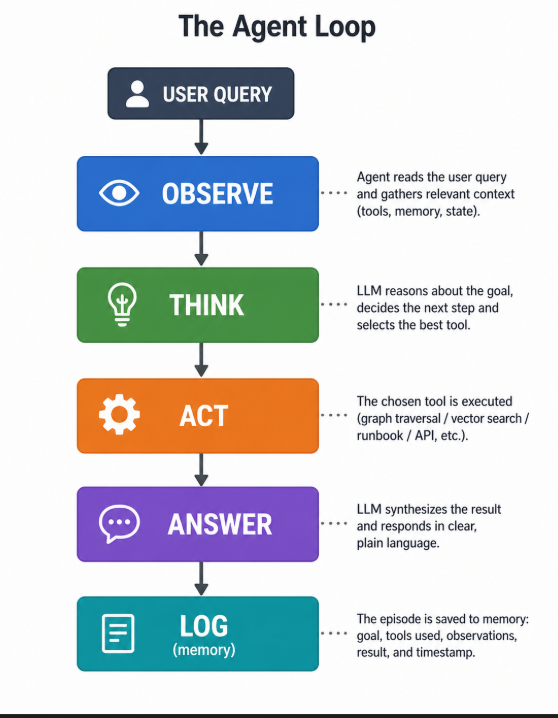

---

## LangChain

LangChain is a framework for building applications powered by language models. It provides the glue between prompts, model calls, output parsers, and tools so you can focus on reasoning logic rather than boilerplate.

### Core components used in this notebook

| Component | What it does | Used for |
|---|---|---|
| `ChatPromptTemplate` | Declares prompt structure with named `{slots}` | THINK and ANSWER prompts |
| LCEL `|` operator | Chains `prompt | model | parser` into one callable | Both chains |
| `StrOutputParser` | Extracts the plain text from a model response | Both chains |
| `@tool` decorator | Registers a Python function as an invokable tool | All 3 investigation tools |

### In this notebook, LangChain helps us:

- Build the agent loop: **Think -> Execute -> Answer -> Log**
- Define and register the three investigation tools so the LLM can invoke them by name
- Route each query to the correct tool automatically — no hard-coded if/else logic
- Connect the agent with graph traversal, Vector RAG, and runbooks in a unified interface
- Extend the system cleanly with episodic memory and multi-step reasoning in Part B

### LCEL pipeline anatomy

```
ChatPromptTemplate  |  ChatGoogleGenerativeAI  |  StrOutputParser
   (fills slots)          (calls Gemini API)       (extracts text)
```


## Setup

In [ ]:
!pip install -q langchain-google-genai langchain-core langchain-huggingface networkx sentence-transformers nest_asyncio
print("Packages installed.")

In [ ]:
from __future__ import annotations

import json
import pathlib
import uuid
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import nest_asyncio

nest_asyncio.apply()

from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings

print("Libraries ready.")

In [ ]:
import os

try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
    HF_TOKEN       = userdata.get('HF_TOKEN')
    print("Keys loaded from Colab Secrets.")
except Exception:
    GEMINI_API_KEY = os.getenv('GOOGLE_API_KEY', '')
    HF_TOKEN       = os.getenv('HF_TOKEN', '')
    print("Reading from environment variables.")

GEMINI_MODEL = "gemini-3-flash-preview"
EMBED_MODEL  = "BAAI/bge-small-en-v1.5"
GRAPH_FILE   = "incident_knowledge_graph.graphml"

chat_model = ChatGoogleGenerativeAI(
    model       = GEMINI_MODEL,
    temperature = 0.1,
    google_api_key = GEMINI_API_KEY,
)
print(f"LLM ready — {GEMINI_MODEL}")

embeddings = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
print(f"Embeddings ready — {EMBED_MODEL} (local)")


import pathlib
import shutil
import urllib.request

REPO_RAW_BASE = "https://raw.githubusercontent.com/AmmarMohanna/oreilly-agentic-graphrag/main"


def ensure_repo_asset(source_path, local_path=None):
    """Make a repo asset available in the current runtime.

    Works in Colab when only the notebook was opened, and also works from a
    local checkout when the companion files are already beside the notebook.
    """
    source = pathlib.Path(source_path)
    target = pathlib.Path(local_path or source.name)

    if target.exists():
        print(f"Found {target}")
        return target

    local_candidates = [
        source,
        pathlib.Path.cwd() / source.name,
        pathlib.Path.cwd() / source,
        pathlib.Path.cwd().parent / source,
    ]
    for candidate in local_candidates:
        if candidate.exists():
            shutil.copy(candidate, target)
            print(f"Copied {candidate} -> {target}")
            return target

    url = f"{REPO_RAW_BASE}/{source_path}"
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, target)
    print(f"Saved {target}")
    return target

ensure_repo_asset(
    "4.Agentic_graphrag/incident_knowledge_graph.graphml.xml",
    GRAPH_FILE,
)
ensure_repo_asset(
    "5.Hardening_Production/episodic_memory.graphml.xml",
    "episodic_memory.graphml",
)


---

## Data Layer
In this notebook, we use a saved GraphML file to simulate GraphRAG and build a vector store for retrieval.

**Note:** this is a simplified setup — the full Vector RAG and GraphRAG pipelines from previous notebooks should be reimplemented or imported properly in production.


In [ ]:
G = nx.read_graphml(GRAPH_FILE)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n")
type_counts = Counter(d.get('type', 'unknown') for _, d in G.nodes(data=True))
print("Node types:")
for t, n in sorted(type_counts.items()): print(f'  {t:<20} {n}')

In [ ]:

docs = [
    Document(
        page_content=(
            data.get('summary','') or data.get('description','')
            or f"{node} is a {data.get('type','entity')}"
        ),
        metadata={'name': node, 'type': data.get('type','entity')},
    )
    for node, data in G.nodes(data=True)
]
vector_store = InMemoryVectorStore(embedding=embeddings)
vector_store.add_documents(docs)
print(f"Vector store ready -- {len(docs)} nodes indexed")

Here is a sample runbook data for our runbook lookup

In [ ]:
_RUNBOOKS = {
    "auth_service":     {"owner": "Identity Team",
                         "steps": ["1. kubectl logs -l app=auth-service",
                                   "2. Verify token validation config",
                                   "3. kubectl rollout undo deploy/auth-service",
                                   "4. Flush session cache",
                                   "5. Page Identity Team on-call"]},
    "api_gateway":      {"owner": "Platform Team",
                         "steps": ["1. Check Gateway error rate in Grafana",
                                   "2. Inspect routing config for recent changes",
                                   "3. kubectl rollout undo deploy/api-gateway",
                                   "4. Page Platform Team on-call"]},
    "database_service": {"owner": "Data Engineering Team",
                         "steps": ["1. Check connection pool utilisation",
                                   "2. Kill long-running queries",
                                   "3. Scale read replicas",
                                   "4. Page Data Engineering on-call"]},
    "cache_service":    {"owner": "Infrastructure Team",
                         "steps": ["1. Check cache hit rate",
                                   "2. Review TTL configuration",
                                   "3. Flush stale session keys",
                                   "4. Page Infrastructure Team on-call"]},
    "default":          {"owner": "Platform Team",
                         "steps": ["1. Identify affected service",
                                   "2. Check recent deployments",
                                   "3. Contact owning team",
                                   "4. Review dependency graph"]},
}
print("Runbooks:", list(_RUNBOOKS.keys()))

---

## Skills and Tools

The agent uses a two-layer architecture that separates **what** it can do from **how** it does it.

| Layer | Role | Loaded when |
|---|---|---|
| **Skill** | Name + description (for THINK) + instructions (for ANSWER) | Once at startup |
| **Tool** | Python implementation — executes the skill | On demand, when selected |

### The flow

```
Startup
  Skills loaded into registry
       |
       v  descriptions injected into THINK prompt

Per query
  THINK   LLM reads skill descriptions, outputs a skill name
       |
       v  skill name resolves to a tool
  EXECUTE  Tool runs, returns raw output
       |
       v  skill instructions + tool output injected into ANSWER prompt
  ANSWER   LLM synthesises a plain-English answer
```

### Three skills, three classes of question

| Skill | Trigger | Mechanism |
|---|---|---|
| `vector-lookup` | *What is X? Describe Y.* | Cosine similarity over embedded graph nodes |
| `graph-traversal` | *Who owns X? What caused Y? What depends on Z?* | BFS from seed nodes, 2 hops |
| `runbook-lookup` | *How to fix X? Rollback steps. Who is on-call?* | Inline remediation playbooks |

### Why separate skills from tools?

- **Skills** are the agent's vocabulary. The LLM reasons about skill names and descriptions — it never sees implementation details.
- **Tools** are the engine room. Swapping a vector store or adding a new data source only changes the tool, not the skill description the LLM reads.
- **Instructions** (part of each skill) tell the ANSWER chain how to interpret the raw tool output — without them, the LLM has no guidance on what to emphasise or cite.

The diagram below shows how the two layers connect.

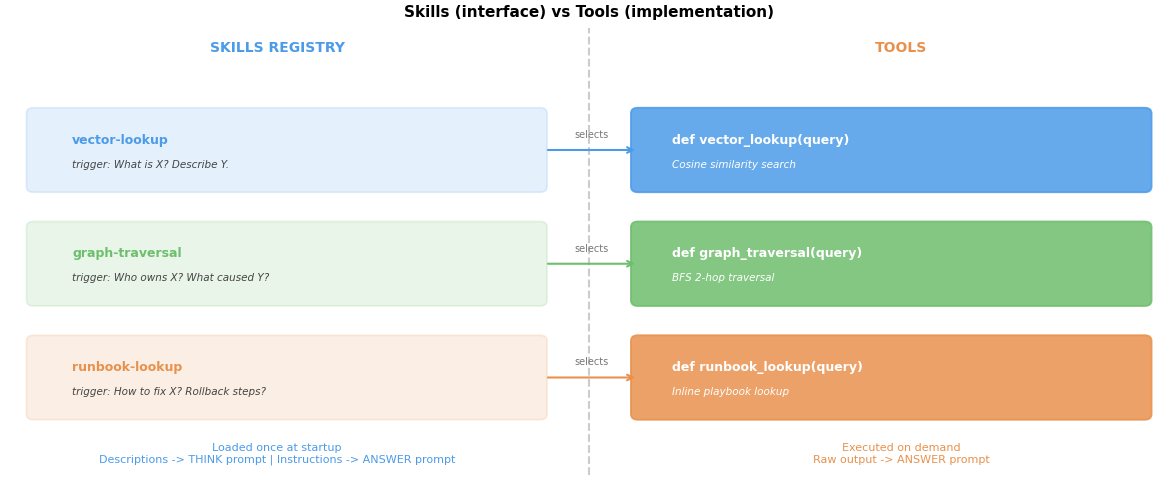

In [ ]:
from dataclasses import dataclass

@dataclass
class SkillDef:
    name:         str
    description:  str   # injected into THINK prompt — LLM reads this to pick the skill
    instructions: str   # injected into ANSWER prompt — guides synthesis after execution

SKILLS = [
    SkillDef(
        name="vector-lookup",
        description=(
            "Semantic search over the knowledge graph. "
            "Use for direct entity questions: what is X, describe Y, tell me about Z."
        ),
        instructions=(
            "The tool returns the top-5 graph nodes most similar to the query, "
            "each with a similarity score and its text summary. "
            "In your answer, cite node names and scores. "
            "Best for: service descriptions, team information, incident summaries."
        ),
    ),
    SkillDef(
        name="graph-traversal",
        description=(
            "Multi-hop graph traversal. "
            "Use for relational questions: who owns X, what caused Y, what depends on Z."
        ),
        instructions=(
            "The tool returns a BFS traversal showing each hop as "
            "source --[REL]--> target [type]. "
            "In your answer, follow the edge chain and explain the relationship path. "
            "Best for: ownership chains, causation paths, dependency trees."
        ),
    ),
    SkillDef(
        name="runbook-lookup",
        description=(
            "Incident remediation runbook. "
            "Use for any how-to-fix or how-to-resolve question: "
            "fix X, resolve X, remediate X, rollback X, steps to handle X, "
            "connection pool, cache, gateway, auth, database issues."
        ),
        instructions=(
            "The tool returns the owner team and ordered remediation steps for the matched service. "
            "In your answer, present the steps clearly and name the on-call team. "
            "Best for: active incidents requiring immediate action."
        ),
    ),
]

SKILLS_MAP = {s.name: s for s in SKILLS}

# Computed ONCE when this cell runs — injected into every THINK prompt unchanged
_SKILL_LIST  = '\n'.join(f'  - {s.name}: {s.description}' for s in SKILLS)
_VALID_NAMES = ', '.join(s.name for s in SKILLS)

print(f"Skills registry: {len(SKILLS)} skills loaded")
for s in SKILLS:
    print(f'  {s.name:<22} description : {s.description[:55]}...')
    print(f'  {"": <22} instructions: {s.instructions[:55]}...')
print()
print("Loaded once at startup:")
print(f"  _SKILL_LIST  = {len(_SKILL_LIST)} chars")
print(f"  _VALID_NAMES = {_VALID_NAMES}")


### Tool Implementations

Each skill is backed by a `@tool`-decorated Python function. Two rules tie skills to tools:

| Tool | Best for |
|---|---|
| `vector-lookup` | 'What is X?', 'Describe Y' |
| `graph-traversal` | 'Who owns X?', 'What caused Y?', 'What depends on Z?' |
| `runbook-lookup` | 'How to fix X?', 'Rollback steps', 'Who is on-call?' |

In [ ]:
# Docstrings below match the corresponding SkillDef.description exactly.
# The LangChain @tool decorator exposes the docstring to the LLM,
# so skill description and tool description are always in sync.

@tool
def vector_lookup(query: str) -> str:
    """Semantic search over the knowledge graph. Use for direct entity questions: what is X, describe Y, tell me about Z."""
    hits = vector_store.similarity_search_with_score(query, k=5)
    if not hits: return 'No relevant nodes found.'
    return '\n'.join(
        f"  {doc.metadata['name']}  (score={score:.3f})\n    {doc.page_content[:120]}"
        for doc, score in hits)

@tool
def graph_traversal(query: str) -> str:
    """Multi-hop graph traversal. Use for relational questions: who owns X, what caused Y, what depends on Z."""
    q_lower    = query.lower()
    direct     = [n for n in G.nodes if n.lower() in q_lower]
    hits       = vector_store.similarity_search(query, k=3)
    vector     = [h.metadata['name'] for h in hits if h.metadata['name'] in G.nodes]
    seen, seed_nodes = set(), []
    for n in direct + vector:
        if n not in seen:
            seen.add(n); seed_nodes.append(n)
    seed_nodes = seed_nodes[:3]

    if not seed_nodes: return 'No relevant graph nodes found.'
    lines    = [f"Seed nodes: {', '.join(seed_nodes)}"]
    visited  = set(seed_nodes)
    frontier = list(seed_nodes)

    # ── Capture edges that connect seed nodes to each other ──────────────────
    for u in seed_nodes:
        for v in seed_nodes:
            if u != v:
                edge = G.get_edge_data(u, v)
                if edge:
                    lines.append(f"{u} --[{edge.get('rel','?')}]--> {v} [{G.nodes[v].get('type','entity')}]")

    # ── BFS ──────────────────────────────────────────────────────────────────
    for hop in range(2):
        nxt    = []
        indent = '  ' * (hop + 1)
        for node in frontier:
            for nb in G.successors(node):
                if nb not in visited:
                    visited.add(nb); nxt.append(nb)
                    rel = (G.get_edge_data(node, nb) or {}).get('rel', '?')
                    lines.append(f"{indent}{node} --[{rel}]--> {nb} [{G.nodes[nb].get('type','entity')}]")
            for nb in G.predecessors(node):
                if nb not in visited:
                    visited.add(nb); nxt.append(nb)
                    rel = (G.get_edge_data(nb, node) or {}).get('rel', '?')
                    lines.append(f"{indent}{nb} --[{rel}]--> {node} [{G.nodes[node].get('type','entity')}]")
        frontier = nxt

    return '\n'.join(lines) if len(lines) > 1 else 'No connected nodes found.'

@tool
def runbook_lookup(query: str) -> str:
    """Incident remediation runbook. Use for how-to-fix questions: steps to resolve, rollback procedure, on-call owner."""
    q = query.lower()
    if   'auth' in q or 'token' in q:      service = 'auth_service'
    elif 'gateway' in q or 'routing' in q: service = 'api_gateway'
    elif 'database' in q or 'pool' in q:   service = 'database_service'
    elif 'cache' in q or 'session' in q:   service = 'cache_service'
    else:                                   service = 'default'
    rb = _RUNBOOKS[service]
    return f"Runbook [{service}]  owner: {rb['owner']}\n" + '\n'.join(rb['steps'])


# Map skill name -> tool (must align with SKILLS_MAP keys)
_TOOLS = {
    'vector-lookup':   vector_lookup,
    'graph-traversal': graph_traversal,
    'runbook-lookup':  runbook_lookup,
}

print("Tools registered (skill name -> implementation):")
for skill_name, t in _TOOLS.items():
    skill = SKILLS_MAP[skill_name]
    print(f'  {skill_name:<22} -> {t.name}()')
    print(f'    instructions: {skill.instructions[:70]}...')

---

## Part A - The Agentic Loop

The core loop calls Gemini **twice** per query:

| Call | Role | Output |
|---|---|---|
| **THINK** | Decide which tool to use | Structured: `THOUGHT: ...` / `SKILL: ...` |
| **ANSWER** | Synthesise tool output | Free-form plain English |

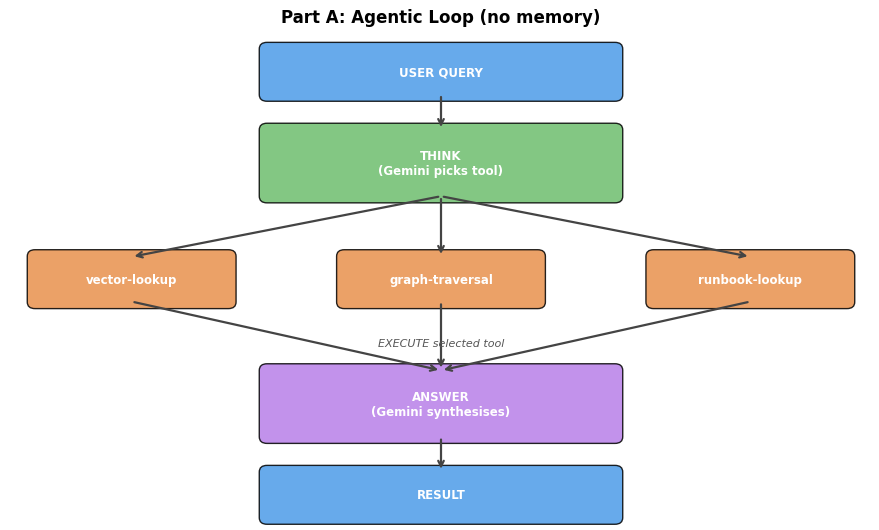

In [ ]:
import re as _re

# THINK: returns JSON so parsing is reliable regardless of markdown/formatting quirks
_THINK_SYS = (
    "You are an agent selecting the right skill to answer the user's query.\n\n"
    "Available skills:\n{skill_list}\n\n"
    "Valid skill names: {valid_names}\n"
    "You MUST pick one skill from the list above. Never use none.\n"
    "If unsure, default to vector-lookup.\n\n"
    "Reply with ONLY a JSON object — no markdown, no code fences:\n"
    "{{\"thought\": \"one sentence explaining your choice\", \"skill\": \"skill-name\"}}"
)
_think_prompt = ChatPromptTemplate.from_messages([
    ("system", _THINK_SYS), ("human", "Query: {query}")])
_think_chain = _think_prompt | chat_model | StrOutputParser()

# ANSWER: grounded strictly in tool output — no outside knowledge
_ANSWER_SYS = (
    "You are an expert SRE analyst.\n\n"
    "Skill instructions:\n{instructions}\n\n"
    "Retrieved context from the knowledge graph:\n{context}\n\n"
    "Rules:\n"
    "- Answer ONLY using the context above. Do not add outside knowledge.\n"
    "- If the context does not contain enough information, say: "
    "'I don't have enough information in the knowledge graph to answer this.'\n"
    "- Cite node names and relationship types where relevant.\n"
    "- Do not show similarity scores."
)
_answer_prompt = ChatPromptTemplate.from_messages([
    ("system", _ANSWER_SYS), ("human", "{query}")])
_answer_chain = _answer_prompt | chat_model | StrOutputParser()

def _parse_think(raw: str):
    """Extract thought + skill from JSON response. Falls back to line parsing if JSON fails."""
    # Strip markdown code fences Gemini sometimes wraps around JSON
    cleaned = _re.sub(r'```(?:json)?\s*|\s*```', '', raw).strip()
    try:
        data   = json.loads(cleaned)
        thought = str(data.get('thought', '')).strip()
        skill   = str(data.get('skill',   '')).strip().lower()
        return thought, skill
    except (json.JSONDecodeError, ValueError):
        # Fallback: line-by-line parsing for malformed responses
        thought = skill = ''
        for line in raw.splitlines():
            clean = line.replace('**', '').replace('*', '').strip()
            if clean.upper().startswith('THOUGHT:'):
                thought = clean.split(':', 1)[1].strip()
            elif clean.upper().startswith('SKILL:'):
                skill = clean.split(':', 1)[1].strip().lower()
        return thought, skill

def _match_skill(raw_skill: str):
    """Resolve LLM output to a _TOOLS key. Tolerates hyphens/spaces/underscores."""
    normalised = raw_skill.replace('-', ' ').replace('_', ' ')
    for name in _TOOLS:
        if name in raw_skill or name.replace('-', ' ') in normalised:
            return name
    return None

def _fallback_skill(query: str):
    """Keyword-based fallback when THINK returns no valid skill (e.g. MALFORMED_RESPONSE)."""
    q = query.lower()
    if any(w in q for w in ['how to', 'fix', 'resolve', 'rollback', 'steps', 'runbook', 'remediat']):
        return 'runbook-lookup'
    if any(w in q for w in ['who owns', 'who is', 'depends', 'caused', 'responsible', 'owner', 'team',
                             'break', 'breaks', 'offline', 'goes down', 'affect', 'impact', 'triggered',
                             'what happens', 'downstream', 'upstream', 'which service']):
        return 'graph-traversal'
    return 'vector-lookup'

print('THINK  -> returns JSON {thought, skill} — robust parsing')
print('ANSWER -> grounded strictly in tool output')
print('_parse_think -> JSON first, line-parsing fallback')
print('_fallback_skill -> keyword routing if Gemini returns MALFORMED_RESPONSE')


In [ ]:
def run_agent(query: str) -> str:
    """THINK -> EXECUTE -> ANSWER (no memory)."""
    div = '=' * 64
    print(f'\n{div}\nQUERY: {query}\n{div}')

    # THINK — _SKILL_LIST injected from startup registry; LLM picks a skill name
    raw = _think_chain.invoke({
        'valid_names': _VALID_NAMES,
        'skill_list':  _SKILL_LIST,
        'query':       query,
    })
    thought, raw_skill = _parse_think(raw)
    matched = _match_skill(raw_skill)

    # Fallback: if THINK returned empty / MALFORMED_RESPONSE, route by keyword
    if matched is None:
        matched = _fallback_skill(query)
        thought = thought or f'[fallback] {matched}'

    print(f'THINK  : {thought}')
    print(f'SKILL  : {matched}')

    # EXECUTE — skill name -> tool implementation; skill instructions loaded from registry
    skill_def    = SKILLS_MAP[matched]            # interface loaded at startup
    instructions = skill_def.instructions         # guides ANSWER synthesis
    tool_output  = _TOOLS[matched].invoke(query)  # tool executes now
    print(f'-- {matched} output -- {tool_output} ---')

    # ANSWER — instructions + raw tool output -> plain-English answer
    answer = _answer_chain.invoke({
        'instructions': instructions,
        'context':      tool_output,
        'query':        query,
    })
    print(f'\nANSWER :\n{answer}\n{div}')
    return answer

print("run_agent() ready.")


### Test the Agent


In [ ]:
run_agent("What does the Cache Service do?")

In [ ]:
run_agent("which services break if Database Service goes offline?")

In [ ]:
run_agent("How do I fix database connection pool exhaustion?")

---

## Part B - Adding Episodic Memory

The agent above forgets everything between calls. Real incidents are recurring: the same Auth Service pattern may reappear next week. **Episodic memory** lets the agent recall past investigations and skip steps it already tried.

### How it works

Every investigation is saved as an **episode node** in a NetworkX graph persisted to disk. When a new query arrives the agent scores past episodes by:

| Signal | Weight | Reason |
|---|---|---|
| Semantic similarity | 60% | Same root cause -> same tools needed |
| Recency (half-life 7 days) | 40% | Recent configs are more accurate |

```
episodic_memory.graphml

ep_001 --[PRECEDED_BY]--> ep_002 --[PRECEDED_BY]--> ep_003
(login slow)               (auth timeout)            (rollback)
```

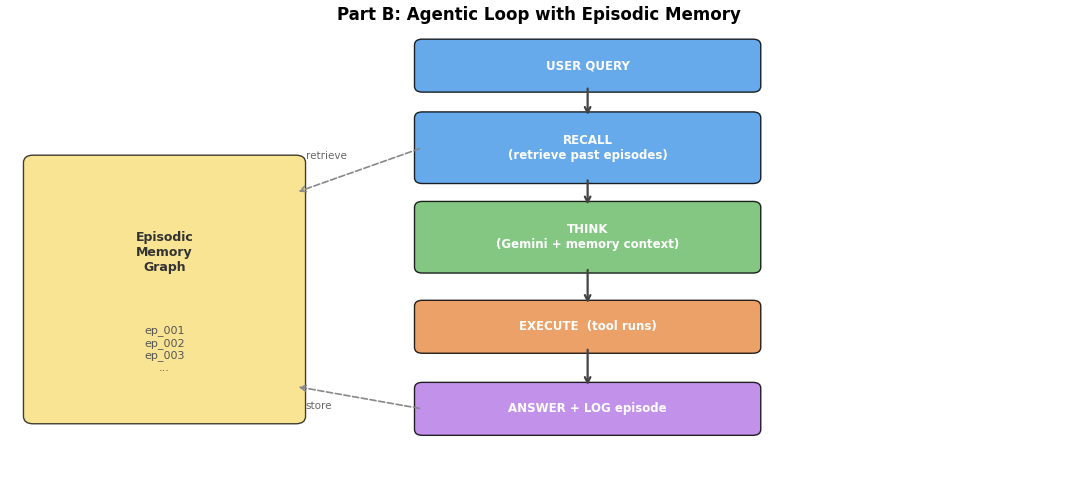

In [ ]:
MEMORY_FILE = pathlib.Path('episodic_memory.graphml')

class EpisodicMemory:
    def __init__(self):
        self._ep = None
        if MEMORY_FILE.exists():
            self._G = nx.read_graphml(str(MEMORY_FILE))
            print(f'Memory loaded -- {self._G.number_of_nodes()} past episodes')
        else:
            self._G = nx.DiGraph()
            print('Memory initialised (empty)')

    def start_episode(self, goal):
        self._ep = f"ep_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:4]}"
        self._G.add_node(self._ep, ts=datetime.now().isoformat(),
                         goal=goal, steps='[]', result='')
        prior = max((n for n in self._G.nodes if n != self._ep),
                    key=lambda n: self._G.nodes[n].get('ts',''), default=None)
        if prior: self._G.add_edge(self._ep, prior, rel='PRECEDED_BY')

    def log_step(self, decision, tool_name, observation):
        steps = json.loads(self._G.nodes[self._ep].get('steps','[]'))
        steps.append({'decision': decision, 'tool': tool_name, 'obs': observation[:200]})
        self._G.nodes[self._ep]['steps'] = json.dumps(steps)

    def end_episode(self, result):
        self._G.nodes[self._ep]['result'] = result[:400]
        nx.write_graphml(self._G, str(MEMORY_FILE))
        print(f'  [MEMORY] Saved -- {self._G.number_of_nodes()} total episodes')

    def retrieve(self, query, k=3):
        """Return k best past episodes: 60% semantic similarity + 40% recency decay."""
        past = [(n,d) for n,d in self._G.nodes(data=True)
                if n != self._ep and d.get('result')]
        if not past: return 'No past episodes.'
        now = datetime.now()
        q_w = {w for w in query.lower().split() if len(w) > 3}
        def score(d):
            g_w = {w for w in d.get('goal','').lower().split() if len(w) > 3}
            sim = len(q_w & g_w) / max(len(q_w | g_w), 1) if q_w else 1.0
            try: age = (now - datetime.fromisoformat(d.get('ts', now.isoformat()))).days
            except ValueError: age = 0
            return 0.6 * sim + 0.4 * (2 ** (-age / 7))
        ranked = sorted(past, key=lambda x: score(x[1]), reverse=True)[:k]
        lines = []
        for _, d in ranked:
            chain = ' -> '.join(s['tool'] for s in json.loads(d.get('steps','[]'))) or 'none'
            lines.append(
                f"[{d.get('ts','')[:19]}] Goal: {d.get('goal','')}\n"
                f"  Tools: {chain}\n  Result: {d.get('result','')[:150]}")
        return '\n\n'.join(lines)

memory = EpisodicMemory()
print("EpisodicMemory ready.")

### Memory-Aware Chains

We extend both prompts with a `{memory_context}` slot so the LLM sees retrieved past episodes.

In [ ]:
# Memory-aware THINK: JSON output — same robust parsing as _THINK_SYS
_THINK_MEM = (
    "You are an agent selecting the right skill to investigate the user's query.\n\n"
    "Past similar incidents (avoid repeating steps already tried):\n{memory_context}\n\n"
    "Observations this session:\n{observations}\n\n"
    "Available skills:\n{skill_list}\n\n"
    "Valid skill names: {valid_names}\n"
    "You MUST pick one skill from the list above. Never use none.\n"
    "If unsure, default to vector-lookup.\n\n"
    "Reply with ONLY a JSON object — no markdown, no code fences:\n"
    "{{\"thought\": \"what you still need to find out\", \"skill\": \"skill-name\"}}"
)
_think_mem_prompt = ChatPromptTemplate.from_messages([
    ("system", _THINK_MEM), ("human", "Query: {query}")])
_think_mem_chain = _think_mem_prompt | chat_model | StrOutputParser()

# Memory-aware ANSWER: grounded in tool output + memory — no outside knowledge
_ANSWER_MEM = (
    "You are an expert SRE analyst.\n\n"
    "Skill instructions:\n{instructions}\n\n"
    "Past episode context (use for questions about previous incidents):\n{memory_context}\n\n"
    "Context retrieved by the skill this session:\n{context}\n\n"
    "Rules:\n"
    "- Answer ONLY using the context above. Do not add outside knowledge.\n"
    "- If the context does not contain enough information, say: "
    "'I don't have enough information in the knowledge graph to answer this.'\n"
    "- Cite node names and relationship types where relevant.\n"
    "- Do not show similarity scores."
)
_answer_mem_prompt = ChatPromptTemplate.from_messages([
    ("system", _ANSWER_MEM), ("human", "{query}")])
_answer_mem_chain = _answer_mem_prompt | chat_model | StrOutputParser()

def _fallback_skill_mem(query: str, memory_context: str):
    """Fallback when memory-aware THINK returns no valid skill."""
    q = query.lower()
    if any(w in q for w in ['how to', 'fix', 'resolve', 'rollback', 'steps', 'runbook', 'remediat']):
        return 'runbook-lookup'
    if any(w in q for w in ['who owns', 'who is', 'depends', 'caused', 'responsible', 'owner', 'team',
                             'break', 'breaks', 'offline', 'goes down', 'affect', 'impact', 'triggered',
                             'what happens', 'downstream', 'upstream', 'which service']):
        return 'graph-traversal'
    return 'vector-lookup'

print('Memory-aware chains ready.')
print('  THINK  -> JSON {thought, skill} — never none')
print('  ANSWER -> grounded in tool output + memory, no outside knowledge')


In [ ]:
def run(query: str) -> str:
    """RECALL -> THINK -> EXECUTE -> ANSWER -> LOG."""
    div = '=' * 64
    print(f'\n{div}\nQUERY: {query}\n{div}')

    # 1. RECALL — retrieve similar past episodes before thinking
    memory.start_episode(query)
    mem_ctx = memory.retrieve(query)
    first = mem_ctx.splitlines()[0] if mem_ctx != 'No past episodes.' else 'none'
    print(f'\nRECALL : {first}')

    # 2. THINK — _SKILL_LIST (startup constant) + memory context; LLM picks skill
    raw = _think_mem_chain.invoke({
        'valid_names':    _VALID_NAMES,
        'skill_list':     _SKILL_LIST,
        'memory_context': mem_ctx,
        'observations':   'None yet.',
        'query':          query,
    })
    thought, raw_skill = _parse_think(raw)
    matched = _match_skill(raw_skill)

    # Fallback: if THINK returned empty (Gemini MALFORMED_RESPONSE), route by keyword
    if matched is None:
        matched = _fallback_skill_mem(query, mem_ctx)
        thought = thought or f'[fallback] {matched}'

    print(f'THINK  : {thought}')
    print(f'SKILL  : {matched}')

    # 3. EXECUTE — skill name -> tool implementation runs
    skill_def    = SKILLS_MAP[matched]             # interface loaded at startup
    instructions = skill_def.instructions          # guides ANSWER synthesis
    tool_output  = _TOOLS[matched].invoke(query)   # tool executes now
    print(f'\n-- {matched} output --\n{tool_output}\n---')
    memory.log_step(thought, matched, tool_output)

    # 4. ANSWER — skill instructions + memory + tool output -> plain-English answer
    answer = _answer_mem_chain.invoke({
        'instructions':   instructions,
        'memory_context': mem_ctx,
        'context':        tool_output,
        'query':          query,
    })

    # 5. LOG — close episode, persist to disk
    memory.end_episode(answer)
    print(f'\nANSWER :\n{answer}\n{div}')
    return answer

print("run() with memory ready.")


### Memory in Action

**Run 1** -- new incident, agent investigates and stores the episode.  
**Run 2** -- same pattern recurs; RECALL surfaces Run 1 so THINK skips already-tried steps.

In [ ]:
# First run — builds the memory episode
run("What deployment triggered INC-003?")


In [ ]:

# Second run — should RECALL the first episode and connect the dots
run("Who should be paged to fix the issue that caused INC-003?")

### Inspect the Memory Graph

In [ ]:
if MEMORY_FILE.exists():
    M = nx.read_graphml(str(MEMORY_FILE))
    print(f'Episodes: {M.number_of_nodes()}   Edges: {M.number_of_edges()}\n')
    fig, ax = plt.subplots(figsize=(10, 4))
    pos = nx.spring_layout(M, seed=42)
    labels = {n: (d.get('goal',n)[:32]+'...') if len(d.get('goal',n)) > 32
              else d.get('goal',n) for n, d in M.nodes(data=True)}
    nx.draw_networkx_nodes(M, pos, node_color='#4C9BE8', node_size=2200, alpha=0.85, ax=ax)
    nx.draw_networkx_labels(M, pos, labels=labels, font_size=7, font_color='black', ax=ax)
    nx.draw_networkx_edges(M, pos, edge_color='#aaa', arrows=True,
                           arrowstyle='-|>', arrowsize=20, ax=ax)
    nx.draw_networkx_edge_labels(M, pos,
        edge_labels={(u,v): d.get('rel','') for u,v,d in M.edges(data=True)},
        font_size=7.5, ax=ax)
    ax.set_title('Episodic Memory Graph -- each node is one investigation episode',
                 fontsize=10, fontweight='bold')
    ax.axis('off'); plt.tight_layout(); plt.show()
else:
    print('No memory file yet -- run the cells above first.')

---

## Summary

| Component | Role |
|---|---|
| LangChain LCEL `|` | Compose prompt + model + parser |
| `vector-lookup` | Semantic entity search |
| `graph-traversal` | Multi-hop relational reasoning |
| `runbook-lookup` | Remediation steps and on-call routing |
| `run_agent()` | Stateless loop -- THINK -> EXECUTE -> ANSWER |
| `EpisodicMemory` | NetworkX graph on disk -- stores every past investigation |
| `run()` | Full loop -- RECALL -> THINK -> EXECUTE -> ANSWER -> LOG |

### What memory adds

- **Speed** -- same root cause? THINK skips the tool and answers from memory directly.
- **Context** -- ANSWER references historical steps and timelines.
- **Audit trail** -- every episode has timestamps and the full tool chain.

***In the next session, we will run a regression test on our golden questions to ensure reliability of our system.***

### Next steps

- Replace `InMemoryVectorStore` with ChromaDB or Pinecone for cross-session persistence.
- Add a second THINK iteration to support multi-tool queries.
- Stream the ANSWER output to a Slack bot or live dashboard.